<a href="https://colab.research.google.com/github/mrendon1998/Maxwell-equations-simulations/blob/main/Ley_de_Gauss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ley de Gauss $ ∇E=\frac{ρ}{ϵ_{0}}$





/tmp/ipykernel_4324/1503891106.py:48: UserWarning: The following kwargs were not used by contour: 'level'
  superficie=ax.contourf(X,Y, V , level=50, cmap='RdBu_r', alpha=0.85)


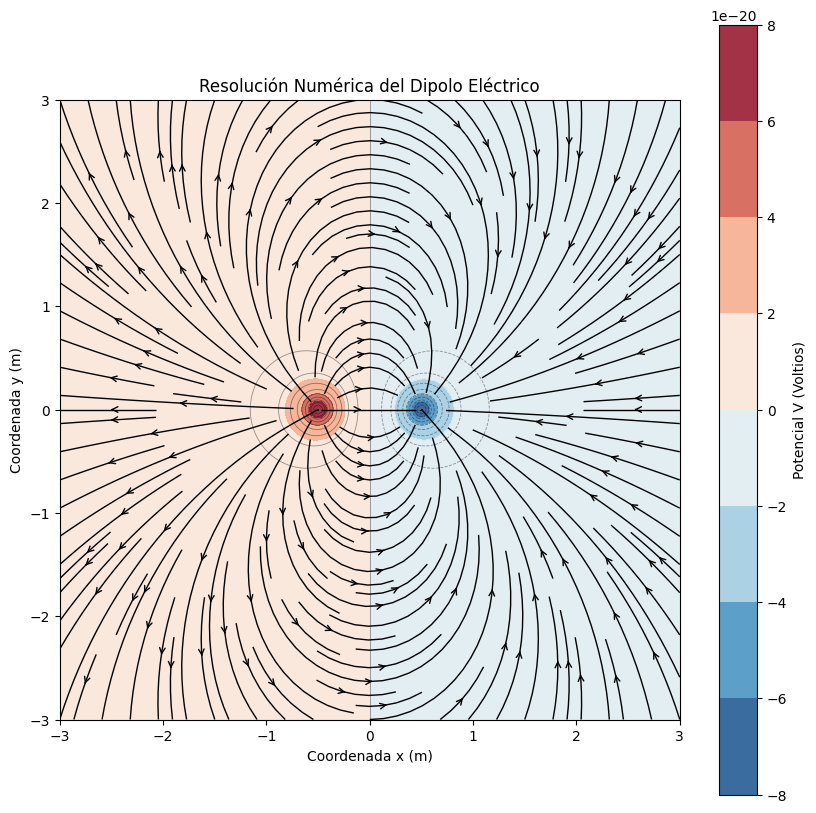

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#-- 1. Definición de parámetros físicos y numéricos --
k_e=8.99e9 # Constante electrostática (N m^2/C^2)
q=1e-9     # Magnitud de carga discreta (1 nC)
d=1.0      # Distancia de separación ddel dipolo (m)
delta=0.1  # Parámetro de suavizado

# Discretización del dominio espacial
L= 3.0         #Límites espaciales [-L,L]
N_nodos= 200  # Resolución de la malla (200x200)
x_1d= np.linspace(-L,L,N_nodos)
y_1d= np.linspace(-L,L,N_nodos)
X, Y = np.meshgrid(x_1d, y_1d) # Generación de los tensores de coordenadas

# --2. Definición del Dipolo
# Carga positiva en el semieje negativo, carga negativa en el semieje positivo

cargas=[
    {'q':q, 'x':-d/2, 'y':0.0},
    {'q':-q, 'x':d/2, 'y':0.0}
]

#-- 3. Evaluación Numérica del potencial escalar (V)

V=np.zeros_like(X)
for carga in cargas:
  r= np.sqrt((X-carga['x'])**2+(Y - carga['y'])**2+delta**2)
  V += carga['q']/(4*np.pi*k_e*r)

#-- 4. Diferenciación numérica E=-grad(V)
# Cálculo de dx y dy

dx=x_1d[1]-x_1d[0]
dy=y_1d[1]-y_1d[0]

# Gradiente respecto al ejeY y el ejeX

E_y,E_x=np.gradient(-V,dy,dx)

# -- 5. Renderizado del espacio de fase

fig1, ax = plt.subplots(figsize=(10,10)) # Tamaño de la figura

# Renderizado del campo escalar V

superficie=ax.contourf(X,Y, V , level=50, cmap='RdBu_r', alpha=0.85)
ax.contour(X,Y,V, levels=25, colors='black', linewidths=0.6, alpha=0.4)
fig1.colorbar(superficie, label= 'Potencial V (Voltios)')

#Renderizado del campo vectorial E

ax.streamplot(X,Y,E_x,E_y, color='black', linewidth=1, density=1.5, arrowstyle='->')

ax.set_title('Resolución Numérica del Dipolo Eléctrico')
ax.set_xlabel('Coordenada x (m)')
ax.set_ylabel('Coordenada y (m)')
ax.set_aspect('equal')
plt.show()




